# Intro Tier: Debugging Tutor Demo

### Using llama.cpp + OpenAI API

This notebook walks you through building a small AI application from scratch: a Socratic debugging tutor. The tutor itself is just the vehicle. The real goal is learning how LLMs work and how to build with them.

### What You Will Build
A chatbot that helps students debug Python code without giving away the answer. Along the way, you will learn the core workflow behind every LLM-powered application.

### Learning Goals

By the end of this notebook, you should be able to:

1. **Design a system prompt** that constrains an LLM to behave a certain way (the tutor rules).
2. **Use few-shot examples** to steer output format and quality without retraining.
3. **Experiment with context scaling**: what happens when you feed the model more (or less) background information?
4. **Compare models** on cost, latency, and output quality, and understand the tradeoffs.
5. **Evaluate LLM outputs** using structured metrics and LLM-as-Judge.
6. **Inspect the full pipeline** through the White Box panel: see exactly what goes in and what comes out.

### Why a Debugging Tutor?
We need a concrete task to make these concepts tangible. Debugging is a good fit because:
- The inputs are short and structured (code + error message).
- The expected output has a clear format (Diagnosis / Root Cause / Check / Review).
- Quality is easy to judge: did the tutor help without giving away the answer?
- Different difficulty levels let us stress-test the LLM in interesting ways.

### Notebook Structure
| Section | What you do | AI concept you learn |
|---------|------------|---------------------|
| 2. Prompting | Write a system prompt + few-shot examples | Prompt engineering, in-context learning |
| 3. Scenarios | Define test inputs at varying difficulty | Evaluation design, input complexity |
| 6. UI + White Box | Run the tutor and inspect internals | Token usage, latency, context window |
| 7. Batch | Run all combinations automatically | Systematic experimentation |
| 8-9. Judge | Score outputs with another LLM | LLM-as-Judge evaluation, quality metrics |

## 1. Setup
Run once.
- installs/imports packages
- sets runtime defaults (`use_gpu`, `n_ctx`, and `n_gpu_layers` from `Guide_Debugging_Tutor.ipynb`.)
- sets model paths


In [2]:
# Step 1: install/import packages used in this notebook.
try:
    import ipywidgets as widgets
    from llama_cpp import Llama
    from openai import OpenAI
    from dotenv import load_dotenv
    import pandas as pd
except Exception:
    %pip -q install ipywidgets llama-cpp-python openai python-dotenv pandas
    import ipywidgets as widgets
    from llama_cpp import Llama
    from openai import OpenAI
    from dotenv import load_dotenv
    import pandas as pd

from pathlib import Path
from IPython.display import display
import os
import json
import time
import gc
import html

# Load OPEN_API_KEY from one env file.
load_dotenv('/home/jovyan/Small_Models_SP26/Seoha/api.env')
openai_api_key = os.getenv('OPEN_API_KEY')

# Runtime defaults.
# Edit use_gpu, n_ctx and n_gpu_layers from Guide_Debugging_Tutor.ipynb, then tune if needed.
use_gpu = True
n_gpu_layers = 28         # Used only when use_gpu=True. If unstable, lower this value.
n_ctx = 1024              # Context window.
max_out_tokens = 192      # Local model output cap. Lower = faster runs.
max_out_tokens_api = 192  # OpenAI output cap.
temp = 0.2                # Lower temperature = more consistent tutoring format.
top_p = 1.0               # Nucleus sampling threshold.
n_threads = 8             # CPU threads for local inference.
n_batch = 128
openai_model = "gpt-5.2"  # OpenAI model name for API runs.
ui_log_rows = 60          # Show only recent rows in run log for speed.

# Local GGUF model files downloaded in /home/jovyan/shared.
models = {
    "Qwen2.5-1.5B (base)": Path("/home/jovyan//Small_Models_SP26/Seoha/Qwen2.5-1.5B.Q4_K_M.gguf"),
    "Qwen2.5-Coder-1.5B (base)": Path("/home/jovyan/Small_Models_SP26/Seoha/Qwen2.5-Coder-1.5B.Q4_K_M.gguf"),
    "Qwen2.5-Coder-1.5B-Instruct": Path("/home/jovyan//Small_Models_SP26/Seoha/qwen2.5-coder-1.5b-instruct-q4_k_m.gguf"),
}
model_options = list(models.keys()) + ["OpenAI (gpt-5.2)"]


# Quick setup check.
model_ready = sum(1 for p in models.values() if p.exists())
print("API key:", "loaded" if openai_api_key else "missing")
print(f"Local GGUF files found: {model_ready}/{len(models)}")


API key: loaded
Local GGUF files found: 3/3


## 2. Prompting

**AI concept:** Prompt engineering and in-context learning.

Every LLM application starts with a prompt. This section defines the two key pieces:

- **System prompt**: Instructions that tell the model *how to behave*. Think of it as the "personality config" for your app. Here, we tell the model to be a Socratic tutor that never gives the answer directly.
- **Few-shot examples**: Input/output pairs that *show* the model what good output looks like. No retraining needed. The model learns the pattern from these examples at inference time.

### What to notice
- The system prompt uses explicit rules ("Max 30 words per section", "Do NOT fix the code"). Small models need clear constraints.
- The few-shot examples cover different error types (runtime vs logic) so the model generalizes rather than memorizing one pattern.

In [3]:
# System prompt
system_message = """
You are a TA helping a student debug their code.
You must NEVER give the corrected code or the direct answer.
Guide the student to find the fix themselves.

Rules:
- Max 30 words per section.
- Do NOT fix the student's code directly.
- You MAY show a short analogous example using DIFFERENT variable names.
  It must NOT be copy-pasteable as the answer.
- If the error is unclear, ask ONE question in Check.

Output format (use these exact headers):

Diagnosis: What symptom the error message describes.
Root cause: Why the code produces that symptom, without revealing the fix.
Check: One step or short example the student can try to verify the cause.
Review: One general principle to prevent this type of bug.
""".strip()

# Few-shot examples
# Chosen to cover two different error categories:
#   Example 1: Runtime error (NameError from a typo). Matches Scenario 1 category.
#   Example 2: Logic error (wrong filter keeps outliers). Matches Scenario 3 category.
# This diversity helps the model generalize to all 5 scenarios.
few_shot_examples = [
    {
        "user": "Student code: totl = price * quantity\n"
                "Error: NameError: name 'totl' is not defined (later in the code)",
        "assistant": "Diagnosis: Python cannot find a variable that was referenced later.\n"
                     "Root cause: The variable name used later does not match the name assigned here.\n"
                     "Check: Compare the exact spelling where you assign vs where you use the variable.\n"
                     "Review: Use consistent, complete variable names and check for typos before running.",
    },
    {
        "user": "Student code: expensive = prices.where('cost', are.above(100))\n"
                "Autograder failed: expected rows where cost <= 100.",
        "assistant": "Diagnosis: The filtered table contains the opposite set of rows.\n"
                     "Root cause: The filter predicate selects rows above the threshold instead of at or below it.\n"
                     "Check: For example, `tbl.where('x', are.above(5))` keeps rows > 5. Which direction does your spec want?\n"
                     "Review: Always re-read the spec to confirm whether you want to keep or remove rows matching the condition.",
    },
]


def get_shot_messages(use_few_shot: bool):
    """Return few-shot messages if enabled, else zero-shot."""
    if not use_few_shot:
        return [], "zero-shot"
    msgs = []
    for ex in few_shot_examples:
        msgs.append({"role": "user", "content": ex["user"]})
        msgs.append({"role": "assistant", "content": ex["assistant"]})
    return msgs, "few-shot"

## 3. Scenarios and Context Scaling

**AI concept:** Evaluation design and context window management.

To evaluate any LLM application, you need good test inputs. These 5 scenarios are our test suite, designed to probe how the model handles different situations:

- **Easy scenarios** (1-2): The error message basically tells you the answer. Can the LLM resist just repeating it?
- **Medium scenario** (3): The code runs fine but produces wrong output. The LLM needs to reason about logic, not just parse an error.
- **Hard scenarios** (4-5): Multiple issues interact. The LLM may need external context (spec, docs) to give useful guidance.

### Context scaling
Each scenario has three optional context layers you can toggle:
- `spec`: What the assignment asks for.
- `docs`: Library reference documentation.
- `course`: Lecture notes with worked examples.

This lets you test a key question in LLM engineering: **does more context always help, or can it hurt?** (Spoiler: it depends on the model and the task.)

In [4]:
# 5 scenarios: universal Python/datascience errors, ordered by difficulty.
# No project-specific domain knowledge required.

# -- Spec excerpts (what the assignment asks) --
spec_1 = """
**Task:** Assign the total cost (price times quantity) for each row to a variable
called `total_cost`, then display the first 5 rows.
""".strip()

spec_2 = """
**Task:** Create a new column called `label` that combines the `city` name
with the `year` as a string, e.g. "Boston 2020". Add it to the table `listings`.
""".strip()

spec_3 = """
**Task:** Remove outlier rows where the per-night price is $1000 or more.
Save the cleaned table to `clean_listings`.
""".strip()

spec_4 = """
**Task:** Create `quantity_demanded`: a cumulative count of bids at each price,
where lower prices should show higher cumulative demand (demand curve slopes down).
""".strip()

spec_5 = """
**Task:** Use the provided `solve` function to find the equilibrium price `P_star`
where supply equals demand. The function returns the x-value (quantity), so you must
substitute back into either equation to get the price.
""".strip()

# -- Docs excerpts (library reference) --
docs_table_ops = """
Source: https://data8.org/fa24/reference/
tbl.where(column, predicate): Keep only rows where predicate is True.
are.equal_to(Z): Equal to Z
are.above(Y): Strictly greater than Y
are.above_or_equal_to(Y): Greater than or equal to Y
are.below(Y): Strictly less than Y
are.below_or_equal_to(Y): Less than or equal to Y
are.between(Y, Z): Greater than or equal to Y and less than Z
tbl.column(name): Returns an array of values from the named column.
tbl.with_column(name, values): Returns a new table with an extra column.
""".strip()

docs_array_ops = """
Source: https://data8.org/fa24/reference/
np.arange(start, stop, step): Array from start up to (not including) stop.
np.cumsum(array): Cumulative sum of array elements.
np.flip(array): Reverse the order of array elements.
str(x): Convert x to a string.
""".strip()

# -- Course excerpts (lecture/textbook examples) --
course_tables = """
Source: Lecture 2 - Working with Tables
# Renaming and selecting columns
clean = raw_tbl.select('price', 'city').relabeled('price', 'Price USD')
# Filtering with predicates
weekday_only = listings.where('day_of_week', are.below(5))
""".strip()

course_demand = """
Source: Lecture 3 - Demand Curves
# Demand curve: cumulative count from HIGH price down to LOW price.
# At a low price, many buyers are willing to pay, so cumulative demand is high.
# np.flip + np.cumsum + np.flip gives a "reverse cumulative sum."
demand = np.flip(np.cumsum(np.flip(bids.column('count'))))
""".strip()

course_equilibrium = """
Source: Lecture 4 - Supply and Demand
# solve() returns the Q where supply and demand intersect.
# That Q is the equilibrium *quantity*, not the price.
# Substitute Q back into inverse_demand(Q) or inverse_supply(Q) to get P_star.
Q_star = solve(demand_eq - supply_eq, Q)[0]
P_star = inverse_demand(Q_star)
""".strip()


# -- Scenario definitions --
scenarios = {
    1: {
        "id": 1,
        "title": "NameError: variable typo [Easy]",
        "difficulty": "easy",
        "error_type": "NameError (runtime)",
        "student_code": (
            "total_cost = listings.column('price') * listings.column('quantity')\n"
            "total_cosst  # typo: extra s"
        ),
        "autograder_failure": "NameError: name 'total_cosst' is not defined",
        "spec": spec_1,
        "docs": docs_table_ops,
        "course": course_tables,
    },
    2: {
        "id": 2,
        "title": "TypeError: string + int [Easy]",
        "difficulty": "easy",
        "error_type": "TypeError (runtime)",
        "student_code": (
            "label = listings.column('city') + listings.column('year')"
        ),
        "autograder_failure": (
            "TypeError: ufunc 'add' did not contain a loop with signature "
            "matching types (dtype('<U'), dtype('int64')) -> None"
        ),
        "spec": spec_2,
        "docs": docs_table_ops,
        "course": course_tables,
    },
    3: {
        "id": 3,
        "title": "Logic error: wrong filter direction [Medium]",
        "difficulty": "medium",
        "error_type": "Logic error (no crash)",
        "student_code": (
            "clean_listings = listings.where('price', are.above_or_equal_to(1000))"
        ),
        "autograder_failure": (
            "AssertionError: expected fewer rows after removing outliers, "
            "but table has only the expensive rows."
        ),
        "spec": spec_3,
        "docs": docs_table_ops,
        "course": course_tables,
    },
    4: {
        "id": 4,
        "title": "Off-by-one: cumsum direction [Hard]",
        "difficulty": "hard",
        "error_type": "Logic error (wrong output shape)",
        "student_code": (
            "quantity_demanded = np.cumsum(demand_binned.column('count'))"
        ),
        "autograder_failure": (
            "Array mismatch: quantity_demanded is increasing with price, "
            "but demand should decrease as price rises."
        ),
        "spec": spec_4,
        "docs": docs_array_ops,
        "course": course_demand,
    },
    5: {
        "id": 5,
        "title": "Multi-step: equilibrium price [Hard]",
        "difficulty": "hard",
        "error_type": "Multi-step logic error",
        "student_code": (
            "P_star = solve(demand_eq + supply_eq, P)[0]"
        ),
        "autograder_failure": (
            "Scalar mismatch: P_star does not satisfy the equilibrium check. "
            "Hint: make sure you are solving for the right variable."
        ),
        "spec": spec_5,
        "docs": docs_array_ops,
        "course": course_equilibrium,
    },
}

print("Scenarios loaded:", len(scenarios))
for sid, s in scenarios.items():
    print(f"  {sid}. [{s['difficulty'].upper():6s}] {s['title']}")
    print(f"     Error type: {s['error_type']}")
    print(f"     Code: {s['student_code'][:70]}...")
    print()

Scenarios loaded: 5
  1. [EASY  ] NameError: variable typo [Easy]
     Error type: NameError (runtime)
     Code: total_cost = listings.column('price') * listings.column('quantity')
to...

  2. [EASY  ] TypeError: string + int [Easy]
     Error type: TypeError (runtime)
     Code: label = listings.column('city') + listings.column('year')...

  3. [MEDIUM] Logic error: wrong filter direction [Medium]
     Error type: Logic error (no crash)
     Code: clean_listings = listings.where('price', are.above_or_equal_to(1000))...

  4. [HARD  ] Off-by-one: cumsum direction [Hard]
     Error type: Logic error (wrong output shape)
     Code: quantity_demanded = np.cumsum(demand_binned.column('count'))...

  5. [HARD  ] Multi-step: equilibrium price [Hard]
     Error type: Multi-step logic error
     Code: P_star = solve(demand_eq + supply_eq, P)[0]...



In [5]:

# Context scaling options (multi-select).

def build_scenario_input(sid: int, selected_ctx):
    """Build scenario input with selected context snippets."""
    s = scenarios[int(sid)]
    parts = [
        f"Scenario: {s['title']}",
        "",
        "Student code:",
        s["student_code"],
        "",
        "Autograder failed:",
        s["autograder_failure"],
    ]

    selected_ctx = selected_ctx or []
    used = []
    for key in ["spec", "docs", "course"]:
        if key in selected_ctx:
            parts.extend(["", f"{key.capitalize()}:", (s[key] or "").strip()])
            used.append(key)

    ctx_key = "+".join(used) if used else "base"
    return s["title"], "\n".join(parts), ctx_key


### Reflection: Before You Experiment

Before running the tutor, make predictions. Good AI engineering starts with hypotheses.

1. **Context window:** The small local models have a 1024-token context window. Looking at Scenario 5 with all three context layers, do you think the full prompt will fit? What happens if it does not?
2. **Few-shot tradeoff:** Few-shot examples take up tokens in the context window. When might it be better to skip them and use those tokens for more context instead?
3. **Model capability:** On Scenario 1 (simple NameError), do you expect a meaningful difference between the 1.5B local model and GPT-5.2? What about on Scenario 5?

## 4. Logs
`/home/jovyan/Small_Models_SP26/logs.jsonl`


In [6]:
# Step 4: set log paths and load previous logs.

def ensure_log_path(path: Path, fallback: str):
    """Create parent directory if possible, otherwise use local fallback path."""
    try:
        path.parent.mkdir(parents=True, exist_ok=True)
        return path
    except Exception:
        local = Path(fallback)
        local.parent.mkdir(parents=True, exist_ok=True)
        return local


logs_path = ensure_log_path(Path("/home/jovyan/Small_Models_SP26/logs.jsonl"), "./logs.jsonl")
judge_logs_path = ensure_log_path(Path("/home/jovyan/Small_Models_SP26/judge_logs.jsonl"), "./judge_logs.jsonl")

# Columns shown in the run log text table.
log_display_cols = [
    "scenario", "model", "shot", "context",
    "in_tok", "out_tok", "lat_s", "cost_usd", "preview"
]


def preview_token(text: str):
    """One-word preview for compact run log display."""
    text = (text or "").strip()
    return text.split()[0] if text else ""


def load_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception:
                pass
    return rows


def append_jsonl(path: Path, row: dict):
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")


def normalize_run_row(row: dict):
    defaults = {
        "scenario": "", "model": "", "shot": "", "context": "",
        "in_tok": "", "out_tok": "", "lat_s": "", "cost_usd": "",
        "response": "", "preview": "",
    }
    out = dict(defaults)
    out.update(row or {})
    if not out.get("preview"):
        out["preview"] = preview_token(out.get("response", ""))
    return out


log_rows = [normalize_run_row(r) for r in load_jsonl(logs_path)]
print("Loaded log rows:", len(log_rows))
print("Logs file:", logs_path)
print("Judge logs file:", judge_logs_path)


Loaded log rows: 0
Logs file: /home/jovyan/Small_Models_SP26/logs.jsonl
Judge logs file: /home/jovyan/Small_Models_SP26/judge_logs.jsonl


## 5. Runners, Metrics, and Logging
- Part A: helpers + summaries
- Part B: ask/run + new chat callbacks

In [7]:
import threading

cache = {"name": None, "llm": None}
run_lock = threading.Lock()


def clear_cache():
    if cache["llm"] is not None:
        del cache["llm"]
    cache["name"] = None
    cache["llm"] = None
    gc.collect()


def load_local_llm(model_name: str):
    """Load one GGUF model (CPU caches one, GPU reloads each run)."""
    model_path = models[model_name]
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")

    if use_gpu:
        clear_cache()
        return Llama(
            model_path=str(model_path),
            n_ctx=n_ctx,
            n_gpu_layers=n_gpu_layers,
            n_threads=n_threads,
            n_batch=n_batch,
            verbose=False,
        )

    if cache["llm"] is not None and cache["name"] == model_name:
        return cache["llm"]

    clear_cache()
    llm = Llama(
        model_path=str(model_path),
        n_ctx=n_ctx,
        n_gpu_layers=0,
        n_threads=n_threads,
        n_batch=n_batch,
        verbose=False,
    )
    cache["name"] = model_name
    cache["llm"] = llm
    return llm


def log_success(row: dict):
    row = normalize_run_row(row)
    log_rows.append(row)
    append_jsonl(logs_path, row)


def log_text():
    """Render recent logs as plain text table for the notebook UI."""
    recent = log_rows[-ui_log_rows:] if ui_log_rows > 0 else log_rows
    lines = [" | ".join(log_display_cols)]
    for r in recent:
        lines.append(" | ".join(str(r.get(c, "")) for c in log_display_cols))
    return "\n".join(lines)


def summarize_runs(rows):
    """Summary table for model/shot/context with avg token/latency/cost."""
    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    for col in ["model", "shot", "context", "response"]:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str)

    for col in ["in_tok", "out_tok", "lat_s", "cost_usd"]:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors="coerce")

    summary = (
        df.groupby(["model", "shot", "context"], dropna=False)
          .agg(
              runs=("response", "size"),
              avg_in_tok=("in_tok", "mean"),
              avg_out_tok=("out_tok", "mean"),
              avg_lat_s=("lat_s", "mean"),
              avg_cost_usd=("cost_usd", "mean"),
          )
          .reset_index()
          .sort_values(["model", "shot", "context"])
    )
    return summary


def summarize_judge_rows(rows):
    """Judge summary with quality score for one-glance comparison."""
    if not rows:
        return pd.DataFrame(), pd.DataFrame()

    df = pd.DataFrame(rows)
    defaults = {
        "model": "", "shot": "", "context": "",
        "in_tok": 0, "out_tok": 0, "lat_s": 0, "cost_usd": 0,
        "structure_adherence": 0, "root_cause_score": 0,
        "wrong_guidance": 0, "hallucination_risk": 0, "policy_safe": 0,
    }
    for col, val in defaults.items():
        if col not in df.columns:
            df[col] = val

    for col in [
        "in_tok", "out_tok", "lat_s", "cost_usd",
        "structure_adherence", "root_cause_score",
        "wrong_guidance", "hallucination_risk", "policy_safe",
    ]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df["quality"] = (
        0.35 * df["structure_adherence"] +
        0.35 * (df["root_cause_score"] / 5.0) +
        0.15 * (1 - df["wrong_guidance"]) +
        0.15 * (1 - df["hallucination_risk"])
    )

    summary = (
        df.groupby(["model", "shot", "context"], dropna=False)
          .agg(
              runs=("quality", "size"),
              quality=("quality", "mean"),
              avg_in_tok=("in_tok", "mean"),
              avg_out_tok=("out_tok", "mean"),
              avg_lat_s=("lat_s", "mean"),
              avg_cost_usd=("cost_usd", "mean"),
              structure_rate=("structure_adherence", "mean"),
              root_cause_avg=("root_cause_score", "mean"),
              wrong_guide_rate=("wrong_guidance", "mean"),
              hallucination_rate=("hallucination_risk", "mean"),
              policy_safe_rate=("policy_safe", "mean"),
          )
          .reset_index()
          .sort_values(["quality", "avg_lat_s"], ascending=[False, True])
    )
    return df, summary


In [8]:
def format_mode_text(model_name, shot_label, context_key):
    return (
        "<div style='background:#eef2ff;color:#1e3a8a;padding:8px 12px;"
        "border:1px solid #c7d2fe;border-radius:10px;font-weight:600;font-size:14px;'>"
        f"[MODE] model: {model_name} | shot: {shot_label} | context: {context_key}"
        "</div>"
    )


def run_once(chat_history, model_name, selected_context_keys, shot_mode, selected_scenario, user_note=""):
    # Normalize state values.
    pairs = [list(x) for x in (chat_history or []) if isinstance(x, (list, tuple)) and len(x) == 2]
    user_note = (user_note or "").strip()

    try:
        sid = int(selected_scenario)
        if sid not in scenarios:
            sid = None
    except Exception:
        sid = None

    # Must either choose a scenario or type a question.
    if sid is None and not user_note:
        msg = "Choose a scenario (1-5) or type your own debugging question, then click Ask."
        pairs.append(["", msg])
        return (
            pairs,
            format_mode_text(model_name, shot_mode, "base"),
            model_name, "", "", "", "", msg,
            "", "", "", "", log_text(),
        )

    # Build scenario mode vs free-text mode input.
    if sid is not None:
        scenario_title, scenario_block, context_key = build_scenario_input(sid, selected_context_keys)
        if user_note:
            scenario_block += "\n\nStudent note:\n" + user_note
        scenario_for_log = str(sid)
        chat_user = user_note if user_note else f"[Scenario {sid}] {scenario_title}"
    else:
        scenario_title = "Free question"
        scenario_block = f"Student question:\n{user_note}"
        context_key = "free"
        scenario_for_log = "free"
        chat_user = user_note

    # Shot selection.
    use_few_shot = (shot_mode == "few-shot")
    shot_messages, shot_label = get_shot_messages(use_few_shot)

    # Full prompt payload for learning/inspection.
    if use_few_shot:
        few_shot_text = "\n\n".join(
            [
                f"Example {i+1} - User:\n{ex['user']}\nExample {i+1} - Assistant:\n{ex['assistant']}"
                for i, ex in enumerate(few_shot_examples)
            ]
        )
    else:
        few_shot_text = "(none)"

    actual_context_text = (
        f"[System]\n{system_message}\n\n"
        f"[Few-shot: {shot_label}]\n{few_shot_text}\n\n"
        f"[Student code + autograder + context]\n{scenario_block}"
    )

    messages = [{"role": "system", "content": system_message}] + shot_messages + [{"role": "user", "content": scenario_block}]

    ok = False
    answer, in_tok, out_tok, lat_s, cost_usd = "", "", "", "", ""
    t0 = time.perf_counter()

    if model_name == "OpenAI (gpt-5.2)":
        api_key = (openai_api_key or "").strip()
        if not api_key:
            answer = "❌ OPEN_API_KEY not found. Check /home/jovyan/shared/api.env"
        else:
            try:
                client = OpenAI(api_key=api_key, timeout=60)
                resp = client.chat.completions.create(
                    model=openai_model,
                    messages=messages,
                    max_completion_tokens=max_out_tokens_api,
                    temperature=temp,
                    top_p=top_p,
                )
                answer = (resp.choices[0].message.content or "").strip() or "⚠️ Empty response."
                usage = getattr(resp, "usage", None)
                in_tok = getattr(usage, "prompt_tokens", "") if usage else ""
                out_tok = getattr(usage, "completion_tokens", "") if usage else ""
                lat_s = round(time.perf_counter() - t0, 2)
                if in_tok != "" and out_tok != "":
                    cost_usd = round((in_tok / 1e6) * 1.75 + (out_tok / 1e6) * 14.0, 6)
                ok = True
            except Exception as e:
                answer = f"❌ OpenAI error: {e}"
    else:
        llm = None
        try:
            with run_lock:
                llm = load_local_llm(model_name)
                out = llm.create_chat_completion(
                    messages=messages,
                    max_tokens=max_out_tokens,
                    temperature=temp,
                    top_p=top_p,
                )
            answer = (out["choices"][0]["message"]["content"] or "").strip() or "⚠️ Empty response."
            usage = out.get("usage", {}) if isinstance(out, dict) else {}
            in_tok = usage.get("prompt_tokens", "")
            out_tok = usage.get("completion_tokens", "")
            if in_tok in ("", None, 0) or out_tok in ("", None, 0):
                in_tok = len(llm.tokenize(actual_context_text.encode("utf-8")))
                out_tok = len(llm.tokenize(answer.encode("utf-8")))
            lat_s = round(time.perf_counter() - t0, 2)
            cost_usd = 0.0
            ok = True
        except Exception as e:
            answer = f"Local run failed: {e}"
        finally:
            if use_gpu:
                try:
                    del llm
                except Exception:
                    pass
                gc.collect()

    pairs.append([chat_user, answer])

    # Log only successful runs.
    if ok:
        log_success({
            "scenario": scenario_for_log,
            "model": model_name,
            "shot": shot_label,
            "context": context_key,
            "in_tok": in_tok,
            "out_tok": out_tok,
            "lat_s": lat_s,
            "cost_usd": cost_usd,
            "response": answer,
        })

    return (
        pairs,
        format_mode_text(model_name, shot_label, context_key),
        model_name,
        shot_label,
        scenario_title,
        context_key,
        actual_context_text,
        answer,
        in_tok,
        out_tok,
        lat_s,
        cost_usd,
        log_text(),
    )


## 6. ipywidgets UI

**AI concept:** Inspecting the full LLM pipeline (input tokens, output tokens, latency, cost).

### How to use the UI
1. **Left panel (Debugging Tutor):** Pick a scenario, choose model/shot/context, click Ask.
2. **Right panel (White Box):** This is the most important learning tool. It shows you *exactly* what the model receives and produces.

### What the White Box teaches you
- **Prompt + Context:** See how the system prompt, few-shot examples, and scenario get assembled into one text block. This is what "prompt engineering" looks like in practice.
- **Token counts:** Notice how input tokens grow as you add context. Compare this to the `n_ctx=1024` limit.
- **Latency:** See how response time changes across models and context sizes.
- **Cost:** For the API model, see real dollar costs per query.

### Suggested experiments
| Experiment | What to change | AI concept tested |
|-----------|---------------|-------------------|
| A. Context scaling | Run Scenario 3: base, +spec, +spec+docs, +all | Does more context improve output? At what token cost? |
| B. Few-shot effect | Run Scenario 1: zero-shot then few-shot | Does in-context learning improve format adherence? |
| C. Model comparison | Run Scenario 5 with each model | Cost/latency/quality tradeoff across model sizes |
| D. Context overflow | Run Scenario 5 with all context on a local model | What happens when the prompt exceeds the context window? |

In [9]:
# Step 6: build ipywidgets UI.

# Shared inline styles to keep the UI code compact.
CHAT_STYLE = (
    'height:380px; overflow-y:auto; border:1px solid #cbd5e1; border-radius:12px; '
    'padding:12px; background:#f8fafc; font-size:14px; line-height:1.45;'
)


def render_chat_html(pairs):
    pairs = pairs or []
    parts = [f'<div style="{CHAT_STYLE}">']
    if not pairs:
        parts.append('<div style="color:#475569;">Choose a scenario or type your own question, then click Ask.</div>')
    for user_text, assistant_text in pairs:
        u = html.escape(str(user_text or "")).replace("\n", "<br>")
        a = html.escape(str(assistant_text or "")).replace("\n", "<br>")
        parts.append('<div style="text-align:right; margin:10px 0;">' +
                     f'<span style="display:inline-block; background:#60a5fa; color:#0f172a; border-radius:14px; padding:9px 12px; max-width:85%; text-align:left;">{u}</span></div>')
        parts.append('<div style="text-align:left; margin:10px 0;">' +
                     f'<span style="display:inline-block; background:#fce7f3; color:#4a044e; border-radius:14px; padding:9px 12px; max-width:85%; text-align:left;">{a}</span></div>')
    parts.append('</div>')
    return ''.join(parts)


def status_badge(text):
    colors = {
        "READY": ("#e2e8f0", "#0f172a"),
        "RUNNING": ("#fde68a", "#78350f"),
        "DONE": ("#bbf7d0", "#14532d"),
        "ERROR": ("#fecaca", "#7f1d1d"),
    }
    bg, fg = colors.get(text, colors["READY"])
    return f'<span style="display:inline-block; padding:4px 10px; border-radius:999px; background:{bg}; color:{fg}; font-weight:700; font-size:12px;">{text}</span>'


def launch_tutor_ui():
    from IPython.display import clear_output

    state = {"chat": [], "busy": False}

    # Main widgets
    mode_bar = widgets.HTML(value=format_mode_text("-", "zero-shot", "spec"))
    chat_view = widgets.HTML(value=render_chat_html([]), layout=widgets.Layout(width='100%'))

    model_dd = widgets.Dropdown(options=model_options, value="Qwen2.5-Coder-1.5B-Instruct", layout=widgets.Layout(width='100%'))
    shot_radio = widgets.ToggleButtons(options=["zero-shot", "few-shot"], value="zero-shot", layout=widgets.Layout(width='100%'))

    ctx_spec = widgets.Checkbox(value=True, description="spec")
    ctx_docs = widgets.Checkbox(value=False, description="docs")
    ctx_course = widgets.Checkbox(value=False, description="course")

    scenario_dd = widgets.Dropdown(
        options=[("Type your own (no scenario)", None)] + [(f"{i}. {scenarios[i]['title']}", i) for i in sorted(scenarios.keys())],
        value=1,
        layout=widgets.Layout(width='100%'),
    )
    user_box = widgets.Textarea(
        value="",
        placeholder="Choose a scenario or type your own debugging question.",
        layout=widgets.Layout(width='100%', height='95px'),
    )

    ask_btn = widgets.Button(description="Ask", button_style="success", layout=widgets.Layout(width='120px'))
    new_chat_btn = widgets.Button(description="New Chat", button_style="warning", layout=widgets.Layout(width='120px'))

    # White box
    wb_header = widgets.HTML('<div style="font-size:26px; font-weight:700; color:#0f172a;">White Box</div>')
    wb_status = widgets.HTML(value=status_badge("READY"))
    wb_meta = widgets.HTML('<div style="color:#334155; font-size:14px;">model: - | shot: - | context: -</div>')
    wb_prompt = widgets.Textarea(value="", disabled=True, layout=widgets.Layout(width='100%', height='220px'))
    wb_response = widgets.Textarea(value="", disabled=True, layout=widgets.Layout(width='100%', height='180px'))
    wb_metrics = widgets.HTML('<div style="color:#334155; font-size:14px;">in: - | out: - | latency: - | cost: -</div>')
    wb_error = widgets.HTML(value='')

    log_view = widgets.Textarea(value=log_text(), disabled=True, layout=widgets.Layout(width='100%', height='170px'))

    def ctx_keys():
        return [k for k, c in (("spec", ctx_spec), ("docs", ctx_docs), ("course", ctx_course)) if c.value]

    def set_busy(busy):
        state["busy"] = busy
        ask_btn.disabled = busy
        new_chat_btn.disabled = busy

    def reset_white_box():
        wb_status.value = status_badge("READY")
        wb_meta.value = '<div style="color:#334155; font-size:14px;">model: - | shot: - | context: -</div>'
        wb_prompt.value = ""
        wb_response.value = ""
        wb_metrics.value = '<div style="color:#334155; font-size:14px;">in: - | out: - | latency: - | cost: -</div>'
        wb_error.value = ''

    def on_ask(_):
        if state["busy"]:
            return

        set_busy(True)
        wb_status.value = status_badge("RUNNING")
        wb_error.value = ''

        try:
            out = run_once(
                chat_history=state["chat"],
                model_name=model_dd.value,
                selected_context_keys=ctx_keys(),
                shot_mode=shot_radio.value,
                selected_scenario=scenario_dd.value,
                user_note=user_box.value,
            )
            state["chat"] = out[0]
            chat_view.value = render_chat_html(state["chat"])
            mode_bar.value = out[1]
            log_view.value = str(out[12])

            wb_meta.value = f'<div style="color:#334155; font-size:14px;">model: {html.escape(str(out[2]))} | shot: {html.escape(str(out[3]))} | context: {html.escape(str(out[5]))}</div>'
            wb_prompt.value = str(out[6])
            wb_response.value = str(out[7])
            wb_metrics.value = f'<div style="color:#334155; font-size:14px;">in: {out[8]} | out: {out[9]} | latency: {out[10]}s | cost: {out[11]}</div>'
            wb_status.value = status_badge("DONE")
        except Exception as e:
            wb_status.value = status_badge("ERROR")
            wb_error.value = f'<div style="margin-top:6px; color:#b91c1c; font-size:13px;">Error: {html.escape(str(e))}</div>'
        finally:
            set_busy(False)

    def on_new_chat(_):
        if state["busy"]:
            return
        state["chat"] = []
        chat_view.value = render_chat_html([])
        mode_bar.value = format_mode_text(model_dd.value, shot_radio.value, "+".join(ctx_keys()) if ctx_keys() else "base")
        user_box.value = ""
        log_view.value = log_text()
        reset_white_box()

    ask_btn.on_click(on_ask)
    new_chat_btn.on_click(on_new_chat)

    # Layout
    top_row = widgets.HBox([
        widgets.VBox([widgets.HTML('<b>Model</b>'), model_dd], layout=widgets.Layout(width='49%')),
        widgets.VBox([widgets.HTML('<b>Shot</b>'), shot_radio], layout=widgets.Layout(width='49%')),
    ], layout=widgets.Layout(justify_content='space-between'))

    mid_row = widgets.VBox([
        widgets.HTML('<b>Context (multi-select)</b>'),
        widgets.HBox([ctx_spec, ctx_docs, ctx_course], layout=widgets.Layout(justify_content='space-between')),
    ])

    scenario_col = widgets.VBox([
        widgets.HTML('<b>Scenario</b>'), scenario_dd,
        widgets.HTML('<b style="margin-top:6px;">Type (optional)</b>'), user_box,
    ], layout=widgets.Layout(width='82%'))

    action_col = widgets.VBox([ask_btn, new_chat_btn], layout=widgets.Layout(width='16%', align_items='stretch', gap='8px'))

    controls = widgets.VBox([
        top_row,
        mid_row,
        widgets.HBox([scenario_col, action_col], layout=widgets.Layout(justify_content='space-between', align_items='flex-start')),
    ], layout=widgets.Layout(**{"width":"100%","border":"1px solid #cbd5e1","border_radius":"12px","padding":"10px","margin":"8px 0 0 0"}))

    left = widgets.VBox([
        widgets.HTML('<div style="font-size:26px; font-weight:700; color:#0f172a;">Debugging Tutor</div>'),
        widgets.HTML('<div style="color:#334155; font-size:14px; margin-bottom:6px;">Choose a scenario or type your own question.</div>'),
        mode_bar,
        chat_view,
        controls,
    ], layout=widgets.Layout(width='64%'))

    right_title = widgets.HBox([wb_header, wb_status], layout=widgets.Layout(justify_content='space-between', align_items='center'))

    right = widgets.VBox([
        right_title,
        wb_meta,
        widgets.HTML('<div style="font-size:13px; color:#334155; margin-top:2px;">Prompt + Context</div>'),
        wb_prompt,
        widgets.HTML('<div style="font-size:13px; color:#334155; margin-top:2px;">Response</div>'),
        wb_response,
        wb_metrics,
        wb_error,
    ], layout=widgets.Layout(width='36%', border='1px solid #dbeafe', border_radius='12px', padding='10px', margin='0 0 0 8px'))

    ui = widgets.VBox([
        widgets.HBox([left, right], layout=widgets.Layout(width='100%', align_items='flex-start')),
        widgets.HTML('<b>Run Log</b>'),
        log_view,
    ], layout=widgets.Layout(width='100%'))

    clear_output(wait=True)
    display(ui)


launch_tutor_ui()


### Reflection: After Experimenting

Now that you have run several combinations, answer these AI engineering questions:

1. **Prompt engineering:** Look at the White Box for a zero-shot vs few-shot run on the same scenario. How did the few-shot examples change the output *structure*? Did the model follow the Diagnosis/Root Cause/Check/Review format more reliably?
2. **Context scaling:** Plot (mentally or on paper) the input token count vs response quality across the four context levels. Is the relationship linear? Was there a point of diminishing returns?
3. **Model tradeoff:** Compare the cheapest local model to GPT-5.2 on the same scenario. How much better was the API model? Was it worth the cost and latency difference?
4. **Failure modes:** Find a run where the tutor gave bad advice. Look at the White Box: can you identify *why* from the prompt? Was it missing context, confusing few-shot examples, or a model capability limitation?

## 7. Batch Experiments
Run all model/shot/context/scenario combinations (160 total).
Set `run_batch=True` in the next cell to start.


In [14]:
# Step 7: batch experiment (fixed full grid: 160 runs).
# 4 models x 4 context levels x 2 shot modes x 5 scenarios = 160

run_batch = True  # Set True to run the full batch.

batch_models = model_options[:]  # Include 3 local models + OpenAI
context_sets = [
    [], ["spec"], ["spec", "docs"], ["spec", "docs", "course"],
]
shot_modes = ["zero-shot", "few-shot"]
scenario_ids = [1, 2, 3, 4, 5]

total_runs = len(batch_models) * len(context_sets) * len(shot_modes) * len(scenario_ids)
print(f"Batch plan: {total_runs} runs")

if "OpenAI (gpt-5.2)" in batch_models and not (openai_api_key or "").strip():
    print("OPEN_API_KEY missing: OpenAI rows will return error text.")

if not run_batch:
    print("Batch not started. Set run_batch=True and run this cell again.")
else:
    batch_rows = []
    run_no = 0

    for model_name in batch_models:
        for context_keys in context_sets:
            context_key = "+".join(context_keys) if context_keys else "base"
            for shot_mode in shot_modes:
                for sid in scenario_ids:
                    run_no += 1
                    print(f"[{run_no}/{total_runs}] {model_name} | {shot_mode} | {context_key} | s{sid}")

                    out = run_once(
                        chat_history=[],
                        model_name=model_name,
                        selected_context_keys=context_keys,
                        shot_mode=shot_mode,
                        selected_scenario=sid,
                        user_note="",
                    )

                    _, _, model_out, shot_out, title, _, _, answer, in_tok, out_tok, lat_s, cost_usd, _ = out
                    batch_rows.append({
                        "scenario": sid,
                        "scenario_title": title,
                        "model": model_out,
                        "shot": shot_out,
                        "context": context_key,
                        "in_tok": in_tok,
                        "out_tok": out_tok,
                        "lat_s": lat_s,
                        "cost_usd": cost_usd,
                        "response": answer,
                    })

    print("Batch rows:", len(batch_rows))

    batch_summary = summarize_runs(batch_rows)
    if batch_summary.empty:
        print("No batch summary available.")
    else:
        cols = ["model", "shot", "context", "runs", "avg_in_tok", "avg_out_tok", "avg_lat_s", "avg_cost_usd"]
        print("\nTop 10 fastest settings (avg latency):")
        print(batch_summary.sort_values("avg_lat_s")[cols].head(10).to_string(index=False))

        best = batch_summary.sort_values("avg_lat_s").iloc[0]
        cheapest = batch_summary.sort_values("avg_cost_usd").iloc[0]
        print(f"\nBest latency: {best['model']} | {best['shot']} | {best['context']} | {best['avg_lat_s']:.2f}s")
        print(f"Lowest cost: {cheapest['model']} | {cheapest['shot']} | {cheapest['context']} | ${cheapest['avg_cost_usd']:.6f}")


Batch plan: 160 runs
[1/160] Qwen2.5-1.5B (base) | zero-shot | base | s1


llama_context: n_ctx_per_seq (1024) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


[2/160] Qwen2.5-1.5B (base) | zero-shot | base | s2


llama_context: n_ctx_per_seq (1024) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


[3/160] Qwen2.5-1.5B (base) | zero-shot | base | s3


...

[119/160] Qwen2.5-Coder-1.5B-Instruct | few-shot | spec+docs+course | s4


llama_context: n_ctx_per_seq (1024) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


[120/160] Qwen2.5-Coder-1.5B-Instruct | few-shot | spec+docs+course | s5


llama_context: n_ctx_per_seq (1024) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


[121/160] OpenAI (gpt-5.2) | zero-shot | base | s1
[122/160] OpenAI (gpt-5.2) | zero-shot | base | s2
[123/160] OpenAI (gpt-5.2) | zero-shot | base | s3
[124/160] OpenAI (gpt-5.2) | zero-shot | base | s4
[125/160] OpenAI (gpt-5.2) | zero-shot | base | s5
[126/160] OpenAI (gpt-5.2) | few-shot | base | s1
[127/160] OpenAI (gpt-5.2) | few-shot | base | s2
[128/160] OpenAI (gpt-5.2) | few-shot | base | s3
[129/160] OpenAI (gpt-5.2) | few-shot | base | s4
[130/160] OpenAI (gpt-5.2) | few-shot | base | s5
[131/160] OpenAI (gpt-5.2) | zero-shot | spec | s1
[132/160] OpenAI (gpt-5.2) | zero-shot | spec | s2
[133/160] OpenAI (gpt-5.2) | zero-shot | spec | s3
[134/160] OpenAI (gpt-5.2) | zero-shot | spec | s4
[135/160] OpenAI (gpt-5.2) | zero-shot | spec | s5
[136/160] OpenAI (gpt-5.2) | few-shot | spec | s1
[137/160] OpenAI (gpt-5.2) | few-shot | spec | s2
[138/160] OpenAI (gpt-5.2) | few-shot | spec | s3
[139/160] OpenAI (gpt-5.2) | few-shot | spec | s4
[140/160] OpenAI (gpt-5.2) | few-shot | 

## 8. LLM-as-Judge
- Part A: judge helpers
- Part B: run judge + summary


In [15]:
# Step 8A: judge helper functions.
import hashlib

judge_model = "gpt-5.2"
judge_limit = 160


def make_uid(row):
    key = f"{row.get('scenario','')}|{row.get('model','')}|{row.get('shot','')}|{row.get('context','')}|{row.get('response','')}"
    return hashlib.md5(key.encode("utf-8")).hexdigest()


def parse_json(raw: str):
    raw = (raw or "").strip()
    if not raw:
        return {}
    try:
        return json.loads(raw)
    except Exception:
        a, b = raw.find("{"), raw.rfind("}")
        if a != -1 and b > a:
            try:
                return json.loads(raw[a:b+1])
            except Exception:
                return {}
        return {}


def scenario_packet(row):
    sid = str(row.get("scenario", ""))
    if not sid.isdigit() or int(sid) not in scenarios:
        return "(No scenario metadata)"

    s = scenarios[int(sid)]
    lines = [
        f"Scenario title: {s['title']}",
        f"Student code: {s['student_code']}",
        f"Autograder failed: {s['autograder_failure']}",
    ]
    context_key = str(row.get("context", "") or "")
    if context_key and context_key != "base":
        keys = [k.strip() for k in context_key.split("+") if k.strip()]
        for k in ["spec", "docs", "course"]:
            if k in keys and k in s:
                lines.append(f"{k.capitalize()}: {(s[k] or '').strip()}")
    return "\n".join(lines)


def judge_row(client, row):
    user = (
        "Evaluate this tutoring response. Return strict JSON only.\n\n"
        "Rubric keys:\n"
        "structure_adherence (0/1), root_cause_score (1-5), wrong_guidance (0/1), "
        "hallucination_risk (0/1), policy_safe (0/1), short_reason (string).\n\n"
        f"Scenario packet:\n{scenario_packet(row)}\n\n"
        f"Assistant response to judge:\n{str(row.get('response',''))}"
    )

    resp = client.chat.completions.create(
        model=judge_model,
        messages=[
            {"role": "system", "content": "You are a strict TA evaluator. Return JSON only."},
            {"role": "user", "content": user},
        ],
        temperature=0,
        max_completion_tokens=220,
    )

    raw = (resp.choices[0].message.content or "").strip()
    obj = parse_json(raw)
    return {
        "structure_adherence": int(obj.get("structure_adherence", 0) or 0),
        "root_cause_score": float(obj.get("root_cause_score", 0) or 0),
        "wrong_guidance": int(obj.get("wrong_guidance", 0) or 0),
        "hallucination_risk": int(obj.get("hallucination_risk", 0) or 0),
        "policy_safe": int(obj.get("policy_safe", 0) or 0),
        "short_reason": str(obj.get("short_reason", "")),
        "judge_raw": raw,
    }


In [16]:
# Step 8B: run judge + summary.
base_rows = load_jsonl(logs_path)
if not base_rows:
    print("No logs found. Run scenarios first.")
else:
    target = base_rows[-judge_limit:]
    print(f"Loaded {len(base_rows)} log rows. Evaluating {len(target)} rows.")

    judged_existing = load_jsonl(judge_logs_path)
    judged_uids = {r.get("uid") for r in judged_existing if r.get("uid")}

    pending = []
    for r in target:
        uid = make_uid(r)
        if uid not in judged_uids:
            pending.append({**r, "uid": uid})

    print(f"Already judged: {len(target)-len(pending)} | Pending: {len(pending)}")

    if pending:
        api_key = (openai_api_key or "").strip()
        if not api_key:
            print("OPEN_API_KEY missing. Judge run skipped.")
        else:
            client = OpenAI(api_key=api_key, timeout=90)
            new_rows = []
            for i, row in enumerate(pending, start=1):
                try:
                    score = judge_row(client, row)
                    new_rows.append({
                        "uid": row["uid"],
                        "scenario": row.get("scenario", ""),
                        "model": row.get("model", ""),
                        "shot": row.get("shot", ""),
                        "context": row.get("context", ""),
                        "in_tok": row.get("in_tok", ""),
                        "out_tok": row.get("out_tok", ""),
                        "lat_s": row.get("lat_s", ""),
                        "cost_usd": row.get("cost_usd", ""),
                        "response": row.get("response", ""),
                        **score,
                    })
                except Exception as e:
                    print(f"[{i}/{len(pending)}] judge failed: {e}")
                    continue

                if i % 10 == 0 or i == len(pending):
                    print(f"[{i}/{len(pending)}] judged")

            if new_rows:
                for r in new_rows:
                    append_jsonl(judge_logs_path, r)
                print(f"Saved {len(new_rows)} new judge rows -> {judge_logs_path}")
            else:
                print("No new judge rows saved.")

    all_judged = load_jsonl(judge_logs_path)
    if not all_judged:
        print("No judge logs to summarize yet.")
    else:
        _, summary = summarize_judge_rows(all_judged)
        cols = [
            "model", "shot", "context", "runs", "quality",
            "avg_in_tok", "avg_out_tok", "avg_lat_s", "avg_cost_usd",
            "structure_rate", "root_cause_avg", "wrong_guide_rate", "hallucination_rate",
        ]
        print("\nJudge top 20 by quality:")
        print(summary.sort_values("quality", ascending=False)[cols].head(20).to_string(index=False))

        best = summary.sort_values("quality", ascending=False).iloc[0]
        fastest = summary.sort_values("avg_lat_s").iloc[0]
        print(f"\nBest quality: {best['model']} | {best['shot']} | {best['context']} | q={best['quality']:.3f}")
        print(f"Fastest judged: {fastest['model']} | {fastest['shot']} | {fastest['context']} | {fastest['avg_lat_s']:.2f}s")


Loaded 161 log rows. Evaluating 160 rows.
Already judged: 0 | Pending: 160
[10/160] judged
[20/160] judged
[30/160] judged
[40/160] judged
[50/160] judged
[60/160] judged
[70/160] judged
[80/160] judged
[90/160] judged
[100/160] judged
[110/160] judged
[120/160] judged
[130/160] judged
[140/160] judged
[150/160] judged
[160/160] judged
Saved 160 new judge rows -> /home/jovyan/Small_Models_SP26/judge_logs.jsonl

Judge top 20 by quality:
                      model      shot          context  runs  quality  avg_in_tok  avg_out_tok  avg_lat_s  avg_cost_usd  structure_rate  root_cause_avg  wrong_guide_rate  hallucination_rate
           OpenAI (gpt-5.2)  few-shot        spec+docs     5    1.000       585.4        138.0      2.732      0.002957             1.0             5.0               0.0                 0.0
           OpenAI (gpt-5.2)  few-shot spec+docs+course     5    1.000       653.4        142.0      2.992      0.003131             1.0             5.0               0.0           

## 9. At-a-Glance Comparison
Show compact results from judge logs:
- Leaderboard table (best setting per model)
- Delta table (few-shot gain)
- Graph 1: quality heatmap (model x setting)
- Graph 2: quality vs latency scatter
- Graph 3: few-shot gain bar


Leaderboard (best setting per model):
                      model      shot          context  quality  avg_lat_s  avg_cost_usd  avg_in_tok  avg_out_tok  runs
           OpenAI (gpt-5.2)  few-shot        spec+docs    1.000      2.732      0.002957       585.4        138.0     5
  Qwen2.5-Coder-1.5B (base) zero-shot             base    0.930      9.738      0.000000       224.6        136.6     5
Qwen2.5-Coder-1.5B-Instruct  few-shot spec+docs+course    0.816      5.064      0.000000       666.0         79.0     5
        Qwen2.5-1.5B (base)  few-shot             base    0.758     13.062      0.000000       450.6        192.0     5

Few-shot gain (quality_few - quality_zero):
                      model          context  q_zero  q_few  delta_quality
        Qwen2.5-1.5B (base)             base   0.370  0.758          0.388
  Qwen2.5-Coder-1.5B (base)             spec   0.534  0.768          0.234
  Qwen2.5-Coder-1.5B (base)        spec+docs   0.536  0.742          0.206
           OpenAI

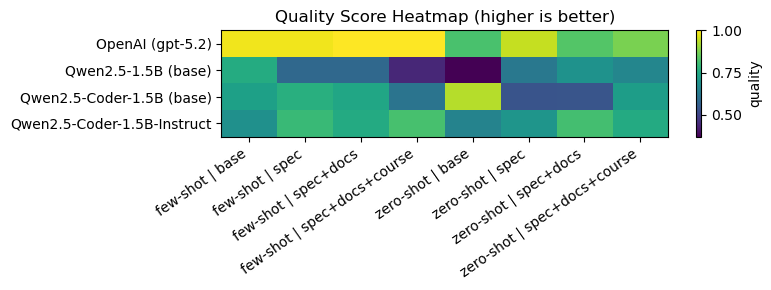

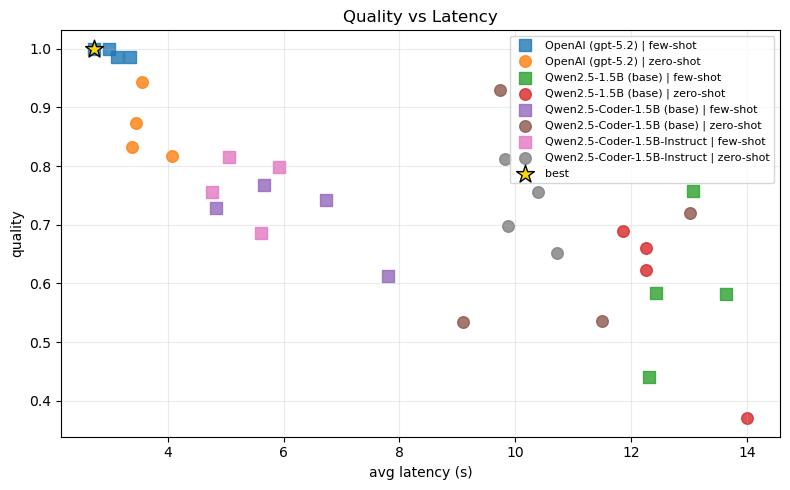

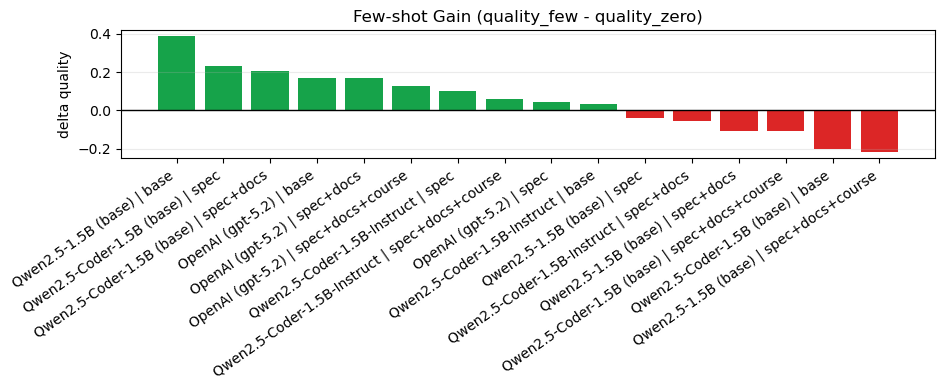

In [17]:
# Step 9: one-glance summary from judge logs.
rows = load_jsonl(judge_logs_path)
if not rows:
    print("No judge logs found. Run Step 8 first.")
else:
    _, summary = summarize_judge_rows(rows)
    if summary.empty:
        print("No judge summary available.")
    else:
        try:
            import matplotlib.pyplot as plt
        except Exception:
            plt = None
            print("matplotlib not available: showing tables only.")

        cols = ["model", "shot", "context", "quality", "avg_lat_s", "avg_cost_usd", "avg_in_tok", "avg_out_tok", "runs"]

        # 1) Leaderboard: best one row per model.
        leaderboard = (
            summary.sort_values(["model", "quality", "avg_lat_s"], ascending=[True, False, True])
                   .groupby("model", as_index=False)
                   .head(1)
                   [cols]
                   .sort_values(["quality", "avg_lat_s"], ascending=[False, True])
        )
        print("Leaderboard (best setting per model):")
        print(leaderboard.to_string(index=False))

        # 2) Delta: few-shot improvement over zero-shot (same model + context).
        zero_df = summary[summary["shot"] == "zero-shot"][["model", "context", "quality"]].rename(columns={"quality": "q_zero"})
        few_df = summary[summary["shot"] == "few-shot"][["model", "context", "quality"]].rename(columns={"quality": "q_few"})
        delta_df = few_df.merge(zero_df, on=["model", "context"], how="inner")

        if delta_df.empty:
            print("\nDelta table unavailable (need both zero-shot and few-shot rows for same model/context).")
        else:
            delta_df["delta_quality"] = delta_df["q_few"] - delta_df["q_zero"]
            delta_df = delta_df.sort_values("delta_quality", ascending=False)
            print("\nFew-shot gain (quality_few - quality_zero):")
            print(delta_df[["model", "context", "q_zero", "q_few", "delta_quality"]].to_string(index=False))

        if plt is not None:
            # Graph 1: quality heatmap (model x shot|context).
            heat_df = summary.copy()
            heat_df["setting"] = heat_df["shot"].fillna("") + " | " + heat_df["context"].fillna("")
            heat_df["setting"] = heat_df["setting"].str.replace(r"^\s*\|\s*", "| ", regex=True)
            heat = heat_df.pivot_table(index="model", columns="setting", values="quality", aggfunc="mean").fillna(0)

            fig, ax = plt.subplots(figsize=(max(8, 0.8 * len(heat.columns)), max(3, 0.75 * len(heat.index))))
            im = ax.imshow(heat.values, aspect="auto", cmap="viridis")
            ax.set_title("Quality Score Heatmap (higher is better)")
            ax.set_xticks(range(len(heat.columns)))
            ax.set_xticklabels(heat.columns, rotation=35, ha="right")
            ax.set_yticks(range(len(heat.index)))
            ax.set_yticklabels(heat.index)
            cbar = plt.colorbar(im, ax=ax)
            cbar.set_label("quality")
            plt.tight_layout()
            plt.show()

            # Graph 2: quality vs latency scatter.
            fig, ax = plt.subplots(figsize=(8, 5))
            marker_map = {"zero-shot": "o", "few-shot": "s"}
            for (model_name, shot_name), g in summary.groupby(["model", "shot"]):
                ax.scatter(
                    g["avg_lat_s"], g["quality"],
                    s=70,
                    alpha=0.8,
                    marker=marker_map.get(shot_name, "o"),
                    label=f"{model_name} | {shot_name}",
                )

            best = summary.sort_values(["quality", "avg_lat_s"], ascending=[False, True]).iloc[0]
            ax.scatter([best["avg_lat_s"]], [best["quality"]], marker="*", s=180, c="gold", edgecolors="black", label="best")

            ax.set_title("Quality vs Latency")
            ax.set_xlabel("avg latency (s)")
            ax.set_ylabel("quality")
            ax.grid(alpha=0.25)
            ax.legend(loc="best", fontsize=8)
            plt.tight_layout()
            plt.show()

            # Graph 3: few-shot gain bar.
            if delta_df.empty:
                print("Few-shot gain bar skipped (no paired zero/few rows).")
            else:
                plot_df = delta_df.copy().sort_values("delta_quality", ascending=False)
                labels = (plot_df["model"] + " | " + plot_df["context"]).tolist()
                vals = plot_df["delta_quality"].tolist()
                colors = ["#16a34a" if v >= 0 else "#dc2626" for v in vals]

                fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(labels)), 4))
                ax.bar(range(len(labels)), vals, color=colors)
                ax.axhline(0, color="black", linewidth=1)
                ax.set_title("Few-shot Gain (quality_few - quality_zero)")
                ax.set_ylabel("delta quality")
                ax.set_xticks(range(len(labels)))
                ax.set_xticklabels(labels, rotation=35, ha="right")
                ax.grid(axis="y", alpha=0.25)
                plt.tight_layout()
                plt.show()


## 10. Final Reflection

### What You Learned About Building with LLMs
Answer these in your own words:

1. **The LLM application stack:** You built a system prompt, added few-shot examples, managed a context window, compared models, and evaluated outputs. Which of these steps had the biggest impact on output quality?
2. **Small vs large models:** In what situations was a 1.5B parameter local model "good enough"? When did you clearly need the API model? What does this mean for real-world deployment decisions?
3. **Evaluation is hard:** The LLM-as-Judge approach uses one model to score another. What are the limitations of this? How might you improve evaluation?
4. **Transferable skills:** The workflow you practiced (prompt design, context management, model comparison, evaluation) applies to *any* LLM application, not just debugging tutors. What other applications could you build using the same approach?
5. **Under the hood:** Before this notebook, how did you think tools like ChatGPT worked? Has anything changed?